[![Roboflow Notebooks](https://media.roboflow.com/notebooks/template/bannertest2-2.png?ik-sdk-version=javascript-1.4.3&updatedAt=1672932710194)](https://github.com/roboflow/notebooks)

# Train Soccer Pitch Keypoint Detector

---

[![Download Dataset](https://app.roboflow.com/images/download-dataset-badge.svg)](https://universe.roboflow.com/roboflow-jvuqo/football-field-detection-f07vi)

This notebook is based on the [How to Train a YOLOv8 Keypint Detection Model](https://github.com/roboflow/notebooks/blob/main/notebooks/train-yolov8-keypoint.ipynb) notebook from the [roboflow/notebooks](https://github.com/roboflow/notebooks) repository.

## Configure API keys

- Open your [`Roboflow Settings`](https://app.roboflow.com/settings/api) page. Click `Copy`. This will place your private key in the clipboard.
- In Colab, go to the left pane and click on `Secrets` (🔑). Store Roboflow API Key under the name `ROBOFLOW_API_KEY`.

## Before you start

Let's make sure that we have access to GPU. We can use `nvidia-smi` command to do that. In case of any problems navigate to `Edit` -> `Notebook settings` -> `Hardware accelerator`, set it to `GPU`, and then click `Save`.

In [1]:
!nvidia-smi

Wed Apr 22 12:20:52 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   41C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
import os
HOME = os.getcwd()
print(HOME)

/content


## Install dependencies

In [3]:
!pip install -q ultralytics roboflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 32.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.9/175.9 kB 21.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 20.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 63.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 146.0 MB/s eta 0:00:00


## Imports

In [4]:
from roboflow import Roboflow
from google.colab import userdata
from IPython.display import Image

## Pull dataset

In [5]:
!mkdir {HOME}/datasets
%cd {HOME}/datasets

ROBOFLOW_API_KEY = userdata.get('ROBOFLOW_API_KEY')
rf = Roboflow(api_key=ROBOFLOW_API_KEY)

project = rf.workspace("roboflow-jvuqo").project("football-field-detection-f07vi")
version = project.version(12)
dataset = version.download("yolov8")

/content/datasets
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to football-field-detection-12 in yolov8:: 100%|██████████| 564/564 [00:00<00:00, 2584.71it/s]


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


**NOTE:** Update `data.yaml` structure to align with the latest requirements of the `ultralytics` package.

In [6]:
!sed -i 's|\(train: \).*|\1../train/images|' {dataset.location}/data.yaml
!sed -i 's|\(val: \).*|\1../valid/images|' {dataset.location}/data.yaml

## Custom training

In [10]:
%cd {HOME}

!yolo task=pose mode=train model=yolov8n-pose.pt \
    data={dataset.location}/data.yaml \
    batch=32 epochs=150 imgsz=640 \
    mosaic=0.0 plots=True \
    patience=30 \
    cos_lr=True \
    device=0

/content
Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/datasets/football-field-detection-12/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=150, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-pose.pt, momentum=0.937, mosaic=0.0, multi_scale=0.0, name=train-2, nbs=64, nms=False, opset=None, optimize=False, optimizer

In [12]:
!ls {HOME}/runs/pose/train/

args.yaml   results.csv       train_batch1.jpg	weights
labels.jpg  train_batch0.jpg  train_batch2.jpg


In [14]:
import os
%cd {HOME}

# Check if the correct directory exists based on the previous training run
run_dir = f'{HOME}/runs/pose/train-2'

# Construct the image path
image_path = f'{run_dir}/results.png'

# Check if the image file actually exists before trying to display it
if os.path.exists(image_path):
    Image(filename=image_path, width=600)
else:
    print(f"Error: The file {image_path} was not found. Please verify the training output directory and file name.")


/content


In [16]:
%cd {HOME}
Image(filename=f'{HOME}/runs/pose/train/val_batch0_pred.jpg', width=600)

/content


FileNotFoundError: [Errno 2] No such file or directory: '/content/runs/pose/train/val_batch0_pred.jpg'

## Validate custom model

In [17]:
%cd {HOME}

!yolo task=pose mode=val model={HOME}/runs/pose/train/weights/best.pt data={dataset.location}/data.yaml

/content
Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv8n-pose summary (fused): 82 layers, 3,670,259 parameters, 0 gradients, 10.9 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3370.5±1129.0 MB/s, size: 234.4 KB)
val: Scanning /content/datasets/football-field-detection-12/valid/labels.cache... 30 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 30/30 6.6Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Pose(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 1.2s/it 2.4s
                   all         30         30      0.853          1      0.995      0.953          0          0          0          0
Speed: 11.8ms preprocess, 26.2ms inference, 0.0ms loss, 3.8ms postprocess per image
Results saved to /content/runs/pose/val
💡 Learn more at https://docs.ultralytics.com/modes/val


In [18]:
%cd {HOME}
!yolo export model={HOME}/runs/pose/train-2/weights/best.pt format=onnx

/content
Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
YOLOv8n-pose summary (fused): 82 layers, 3,670,259 parameters, 0 gradients, 10.9 GFLOPs

PyTorch: starting from '/content/runs/pose/train-2/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 101, 8400) (7.2 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<2.0.0', 'onnxslim>=0.1.71', 'onnxruntime'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 12 packages in 273ms
Prepared 4 packages in 1.50s
Installed 4 packages in 555ms
 + colorama==0.4.6
 + onnx==1.21.0
 + onnxruntime==1.24.4
 + onnxslim==0.1.91

requirements: AutoUpdate success ✅ 2.9s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.21.0 opset 20...
O

/content
Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Loading /content/runs/pose/train-2/weights/best.onnx for ONNX Runtime inference...
requirements: Ultralytics requirement ['onnxruntime-gpu'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 7 packages in 252ms
Prepared 1 package in 2.72s
Installed 1 package in 66ms
 + onnxruntime-gpu==1.24.4

requirements: AutoUpdate success ✅ 3.2s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect

Using ONNX Runtime 1.24.4 with CUDAExecutionProvider
2026-04-22 12:42:29.204557301 [W:onnxruntime:, transformer_memcpy.cc:111 ApplyImpl] 4 Memcpy nodes are added to the graph main_graph for CUDAExecutionProvider. It might have negative impact on performance (including unable to run CUDA graph). Set session_options.log_severity_level=1 to see the detail logs before this message.

image 1/1 /content/datasets/football-field-detection-12/train/images

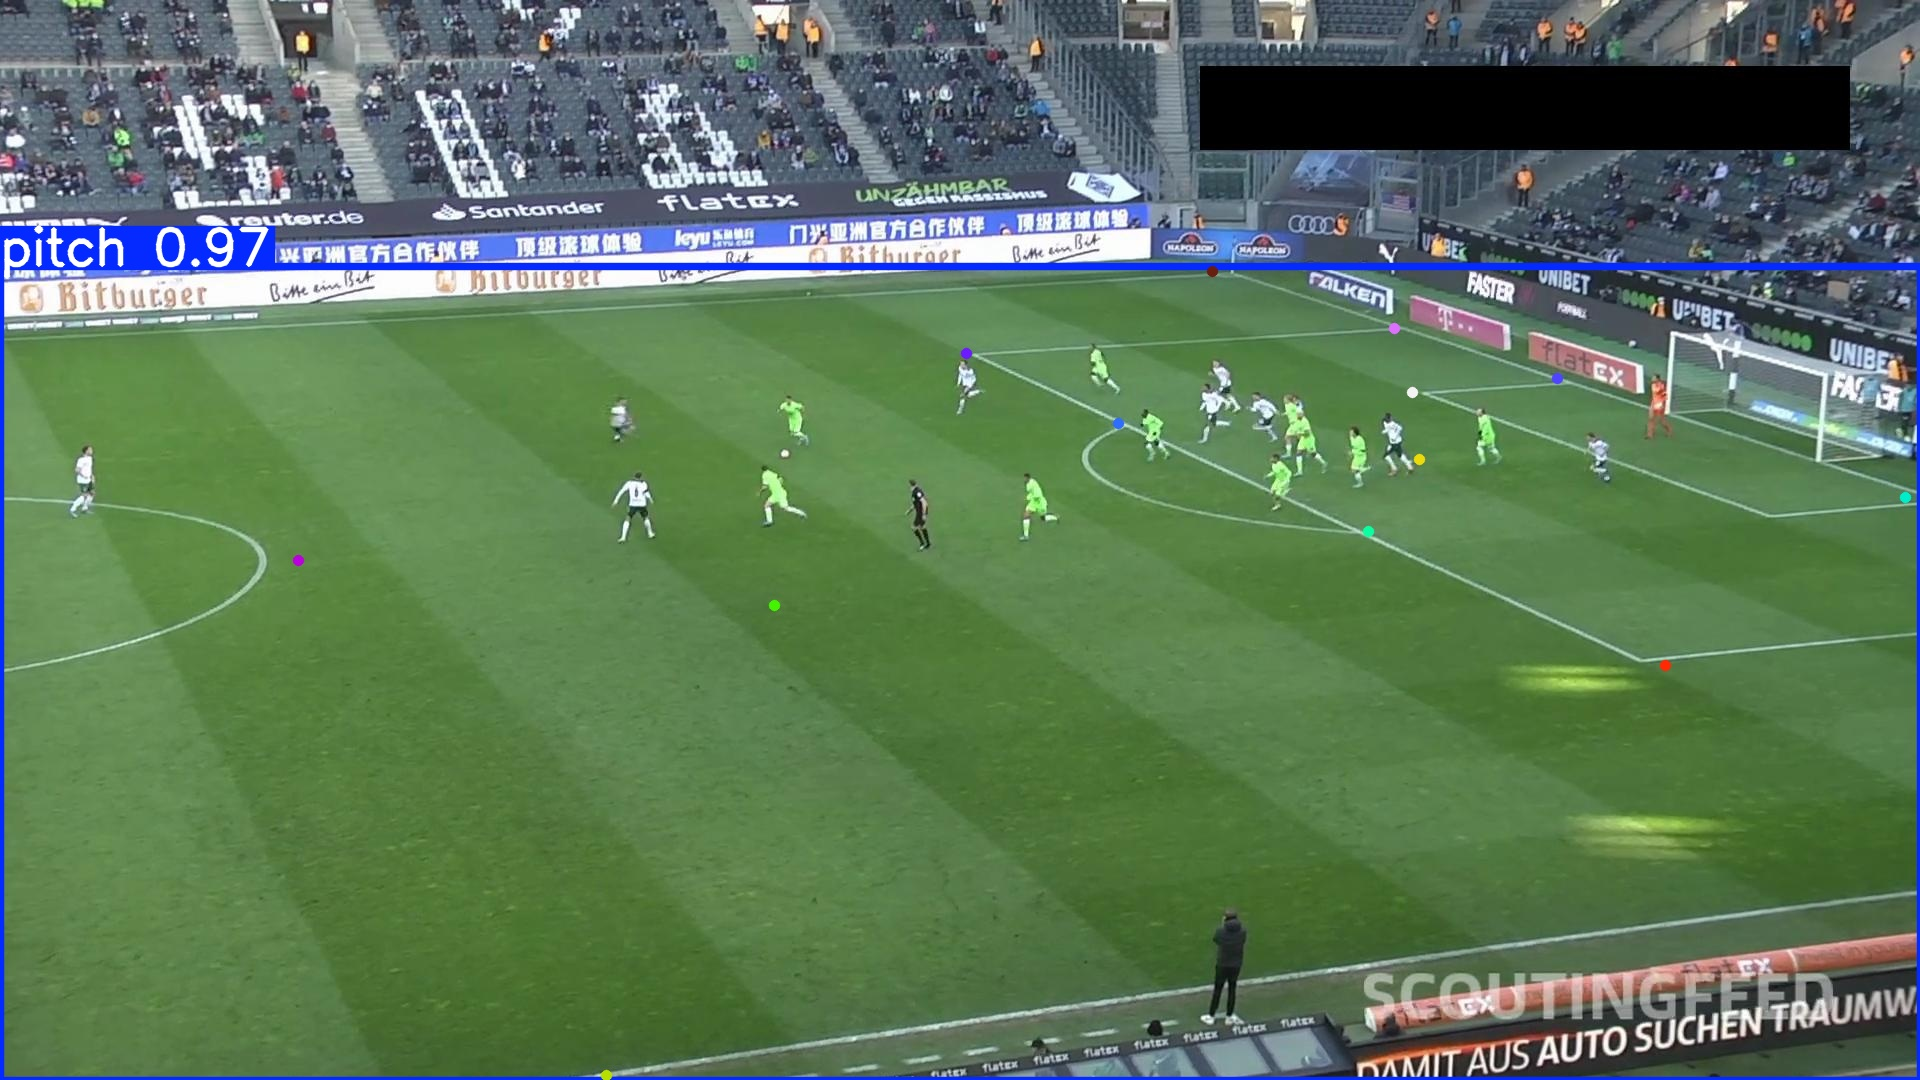

In [21]:
import glob
from IPython.display import Image, display

%cd {HOME}

# Define the path to your test image
# IMPORTANT: Replace 'path/to/your/image.jpg' with the actual path to your image
TEST_IMAGE_PATH = '/content/datasets/football-field-detection-12/train/images/08fd33_2_2_png.rf.850bce4e160a773b54914f318141e15a.jpg'

# Run prediction with the best trained model (using ONNX format)
!yolo task=pose mode=predict model={HOME}/runs/pose/train-2/weights/best.onnx source={TEST_IMAGE_PATH} save=True

# Find the directory where the prediction results are saved
# The predict mode usually creates a 'predict' directory inside 'runs/pose'
predict_run_dir = glob.glob(f'{HOME}/runs/pose/predict*')
if predict_run_dir:
    # Assuming the latest run is the one we just made
    latest_predict_dir = predict_run_dir[-1]
    predicted_image_path = f'{latest_predict_dir}/{os.path.basename(TEST_IMAGE_PATH)}'
    if os.path.exists(predicted_image_path):
        display(Image(filename=predicted_image_path, width=600))
    else:
        print(f"Could not find predicted image at: {predicted_image_path}")
else:
    print("Could not find any prediction run directories.")

## Deploy model on Roboflow

In [24]:
import os
HOME = os.getcwd()

python_code = f"from ultralytics import YOLO; model = YOLO('{HOME}/runs/pose/train-2/weights/best.pt'); print(model.info()); print('Type:', model.task); print('Params:', sum(p.numel() for p in model.model.parameters()))"
!python3 -c "{python_code}"

YOLOv8n-pose summary: 145 layers, 3,676,035 parameters, 0 gradients, 11.0 GFLOPs
(145, 3676035, 0, 10.993971199999999)
Type: pose
Params: 3676035
